In [ ]:
import numpy as np
from torch.utils.data import DataLoader
import pandas as pd
from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms

In [ ]:
Fashion_mnist_test_transform = transforms.Compose([transforms.ToTensor()])
testset_Fashion_mnist = datasets.FashionMNIST(root='./data', train=False, download=True,
                                               transform=Fashion_mnist_test_transform)
FM_test = DataLoader(testset_Fashion_mnist, batch_size=32, shuffle=False, num_workers=2)

FM_test_images = []
FM_test_labels = []
for batch in FM_test:
    images, labels = batch
    images_flat = images.view(images.shape[0], -1)
    FM_test_images.append(images_flat.numpy())
    FM_test_labels.append(labels.numpy())

FM_test_images = np.vstack(FM_test_images)
FM_test_labels = np.concatenate(FM_test_labels)

X_ = pd.DataFrame(data=FM_test_images)
y_ = pd.Series(data=FM_test_labels)

print("FM_test_images shape:", FM_test_images.shape)
print("FM_test_labels shape:", FM_test_labels.shape)

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 303kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.63MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 20.5MB/s]


FM_test_images shape: (10000, 784)
FM_test_labels shape: (10000,)


In [ ]:
# 원본 784차원
X_pca_784 = X_.copy()

# PCA 100차원
pca_100 = PCA(n_components=100, random_state=42)
X_pca_100 = pd.DataFrame(pca_100.fit_transform(X_))

# PCA 50차원
pca_50 = PCA(n_components=50, random_state=42)
X_pca_50 = pd.DataFrame(pca_50.fit_transform(X_))

# PCA 10차원
pca_10 = PCA(n_components=10, random_state=42)
X_pca_10 = pd.DataFrame(pca_10.fit_transform(X_))

print("원본 차원:", X_pca_784.shape)
print("PCA 100차원:", X_pca_100.shape)
print("PCA  50차원:", X_pca_50.shape)
print("PCA  10차원:", X_pca_10.shape)

원본 차원: (10000, 784)
PCA 100차원: (10000, 100)
PCA  50차원: (10000, 50)
PCA  10차원: (10000, 10)


In [ ]:
pca_data = {
    784: X_pca_784.values,
    100: X_pca_100.values,
    50:  X_pca_50.values,
    10:  X_pca_10.values,
}

kmeans_labels = {}
kmeans_ari = {}

for dim in [784, 100, 50, 10]:
    km = KMeans(n_clusters=10, init='k-means++', n_init=10, max_iter=300, random_state=42)
    km.fit(pca_data[dim])
    kmeans_labels[dim] = km.labels_
    ari = metrics.adjusted_rand_score(FM_test_labels, km.labels_)
    kmeans_ari[dim] = ari
    print(f"Dim={dim:4d} | ARI={ari:.4f}")

print("\n===== K-Means ARI 결과 =====")
print(f"{'Dimension':<12} {'ARI'}")
print("-"*20)
for dim in [784, 100, 50, 10]:
    print(f"{dim:<12} {kmeans_ari[dim]:.4f}")

Dim= 784 | ARI=0.3498
Dim= 100 | ARI=0.3402
Dim=  50 | ARI=0.3516
Dim=  10 | ARI=0.3497

===== K-Means ARI 결과 =====
Dimension    ARI
--------------------
784          0.3498
100          0.3402
50           0.3516
10           0.3497


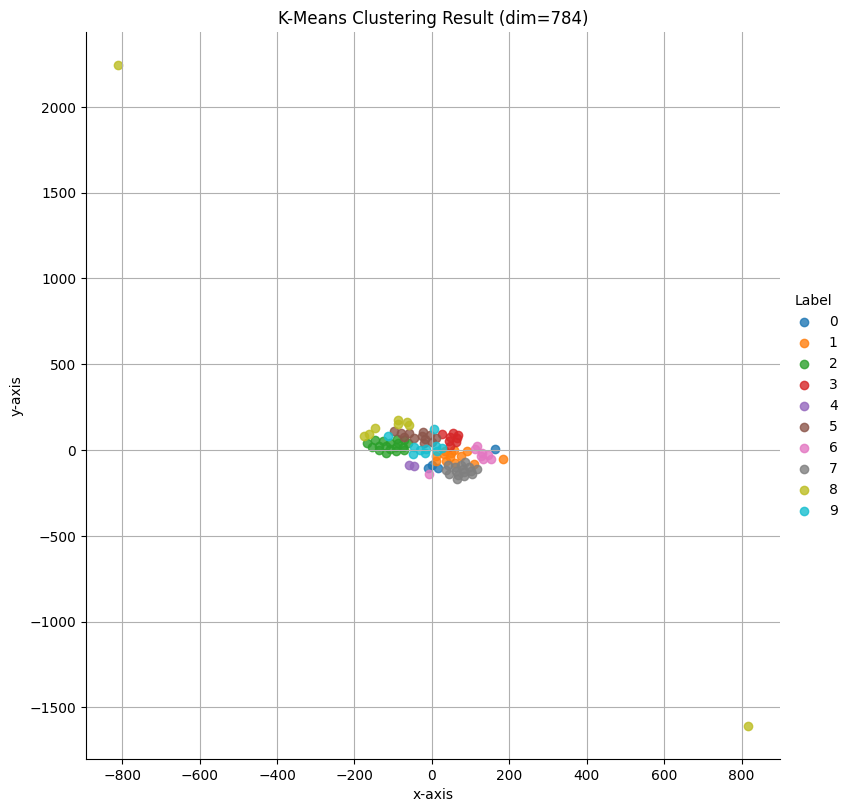

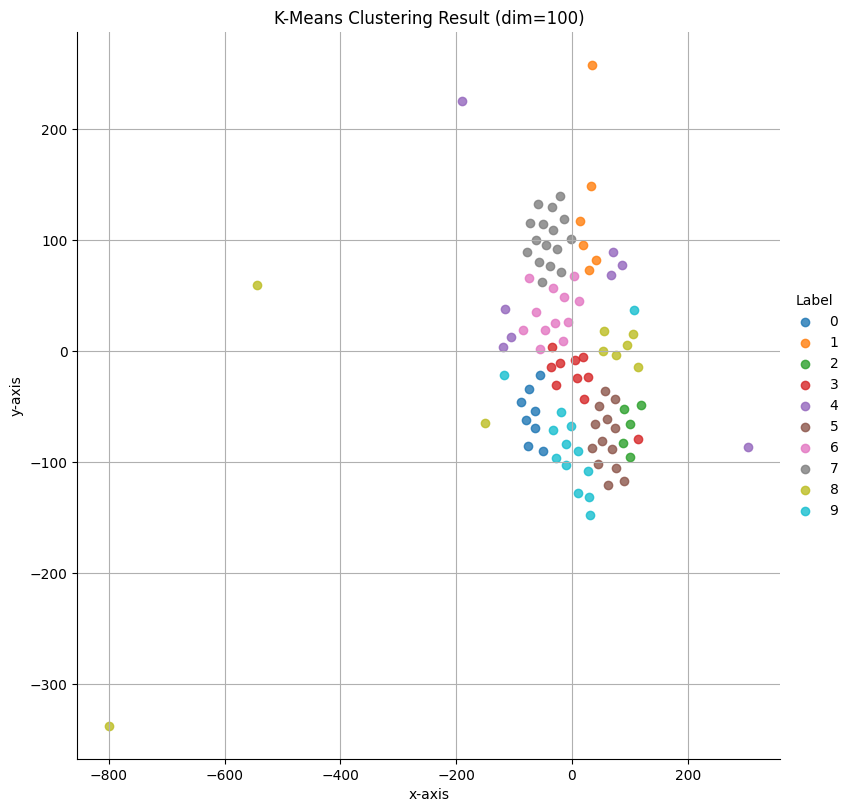

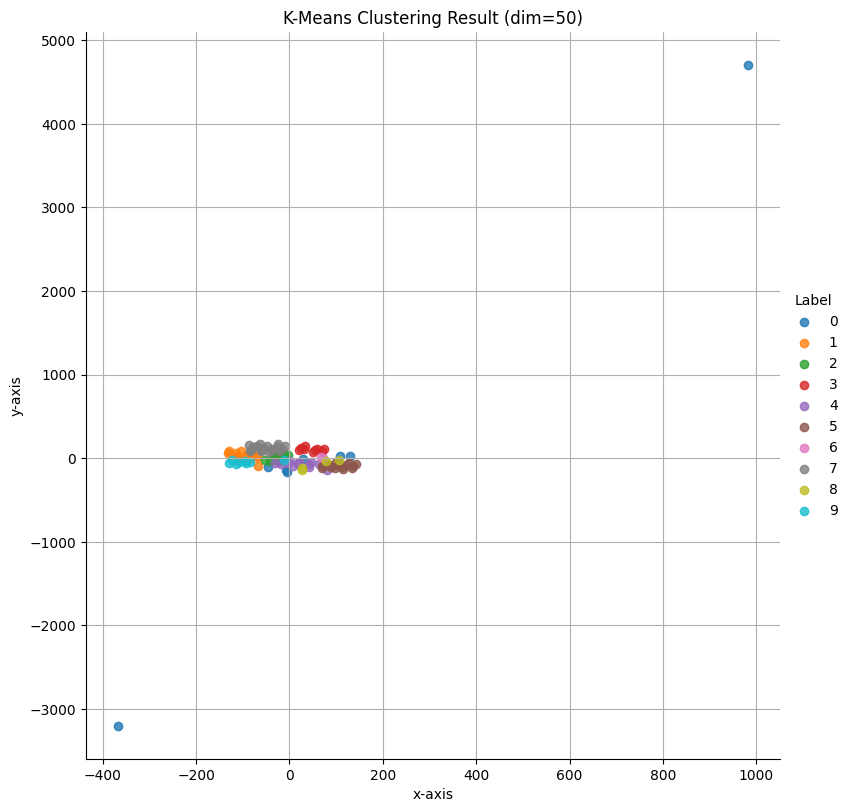

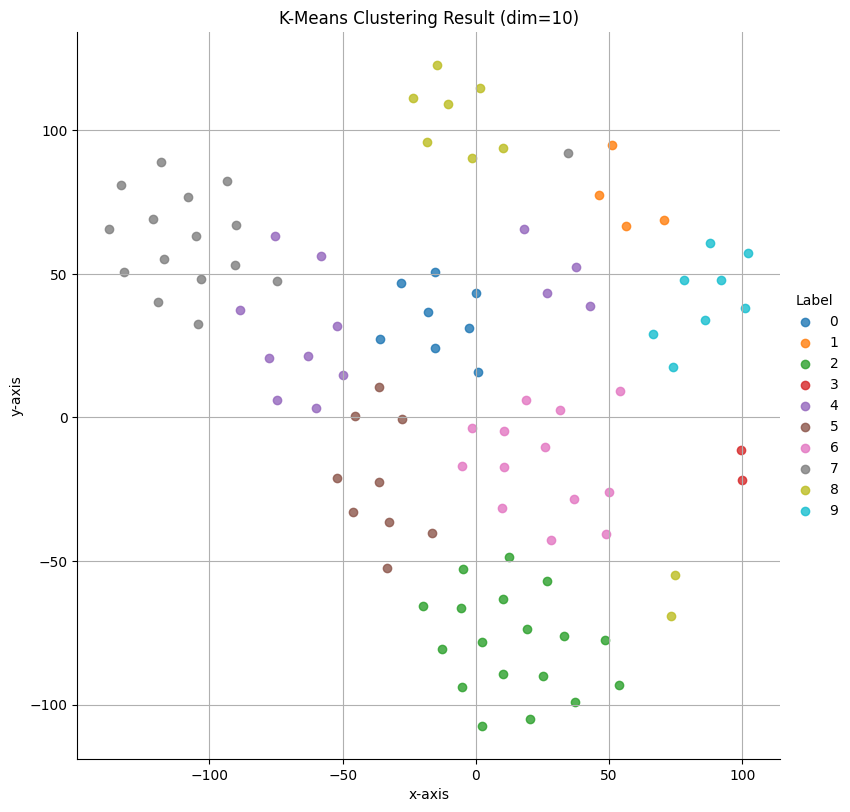

In [ ]:
np.random.seed(42)
sample_idx = np.random.choice(len(FM_test_images), 100, replace=False)

for dim in [784, 100, 50, 10]:
    # 100개 샘플링
    X_sample = pca_data[dim][sample_idx]
    cluster_sample = kmeans_labels[dim][sample_idx]

    # t-SNE
    tSNE = TSNE(n_components=2, learning_rate=300, perplexity=30,
                early_exaggeration=12, init='random', random_state=42)
    X_tsne = pd.DataFrame(tSNE.fit_transform(X_sample))

    # DataFrame 구성
    testDF = pd.DataFrame(data=X_tsne.values, columns=["x-axis", "y-axis"])
    testDF = pd.concat((testDF, pd.Series(cluster_sample, name="Label")), axis=1)

    # 시각화
    sns.lmplot(x="x-axis", y="y-axis", hue="Label", data=testDF, fit_reg=False, height=8)
    plt.title(f"K-Means Clustering Result (dim={dim})")
    plt.grid()
    plt.show()

In [ ]:
dbscan_params = {
    784: {'eps': 10,  'min_samples': 5},
    100: {'eps': 4,   'min_samples': 5},
    50:  {'eps': 3,   'min_samples': 5},
    10:  {'eps': 1.5, 'min_samples': 5},
}

dbscan_labels = {}
dbscan_ari = {}

for dim in [784, 100, 50, 10]:
    eps = dbscan_params[dim]['eps']
    min_samples = dbscan_params[dim]['min_samples']

    db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    db.fit(pca_data[dim])
    dbscan_labels[dim] = db.labels_

    n_clusters = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_noise = np.sum(db.labels_ == -1)
    ari = metrics.adjusted_rand_score(FM_test_labels, db.labels_)
    dbscan_ari[dim] = ari
    print(f"Dim={dim:4d} | eps={eps} | clusters={n_clusters} | noise={n_noise} | ARI={ari:.4f}")

print("\n===== DBSCAN ARI 결과 =====")
print(f"{'Dimension':<12} {'Clusters':<12} {'ARI'}")
print("-"*30)
for dim in [784, 100, 50, 10]:
    n_clusters = len(set(dbscan_labels[dim])) - (1 if -1 in dbscan_labels[dim] else 0)
    print(f"{dim:<12} {n_clusters:<12} {dbscan_ari[dim]:.4f}")

Dim= 784 | eps=10 | clusters=1 | noise=0 | ARI=0.0000
Dim= 100 | eps=4 | clusters=8 | noise=1621 | ARI=0.0070
Dim=  50 | eps=3 | clusters=19 | noise=2708 | ARI=0.0200
Dim=  10 | eps=1.5 | clusters=29 | noise=2417 | ARI=0.1722

===== DBSCAN ARI 결과 =====
Dimension    Clusters     ARI
------------------------------
784          1            0.0000
100          8            0.0070
50           19           0.0200
10           29           0.1722


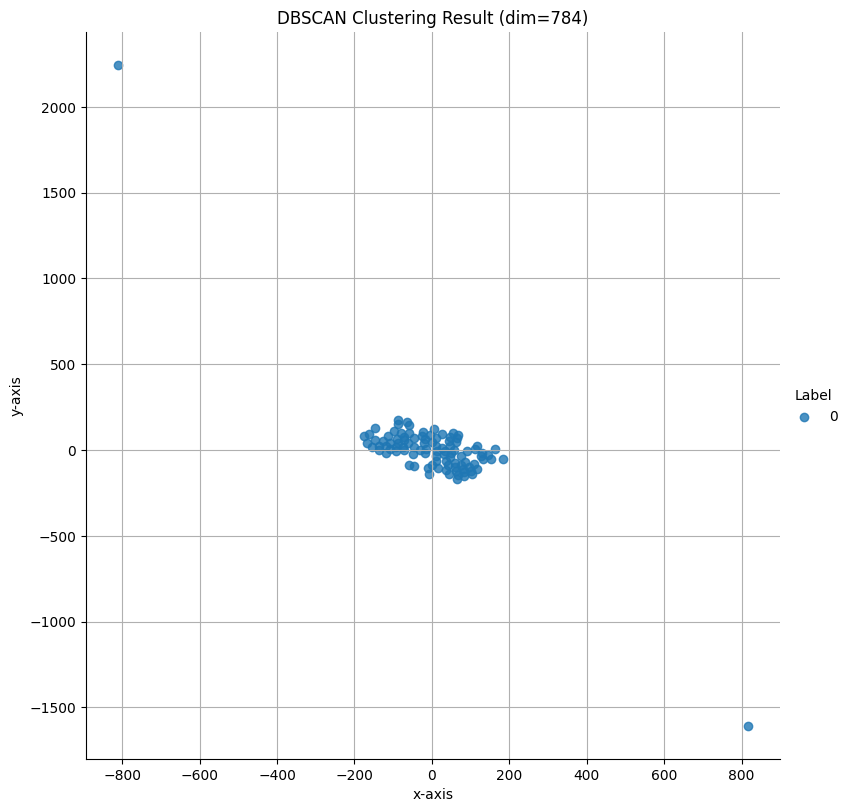

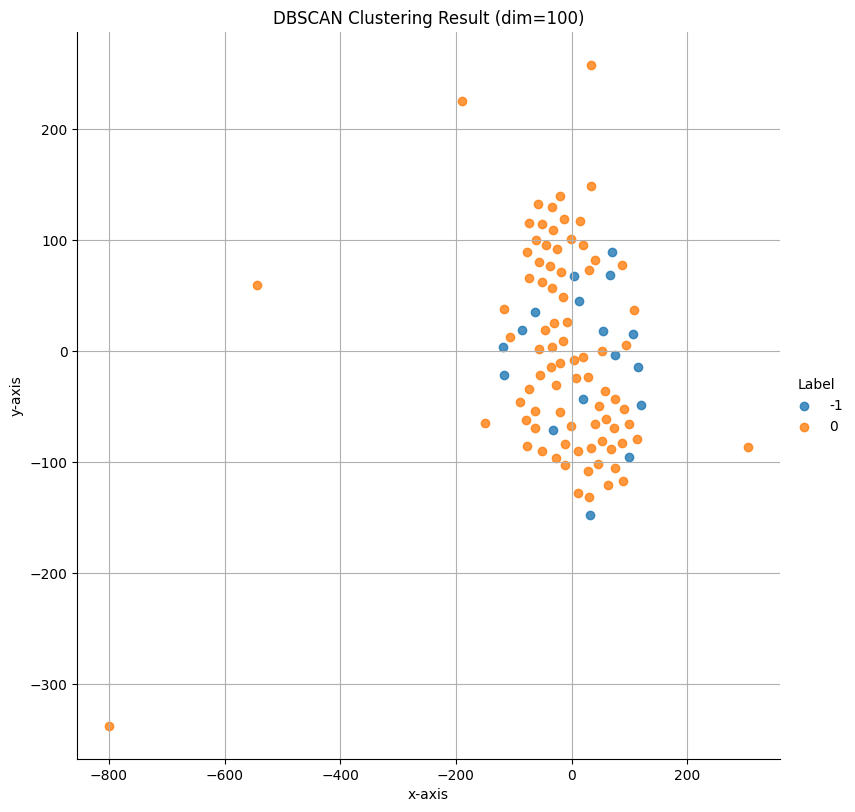

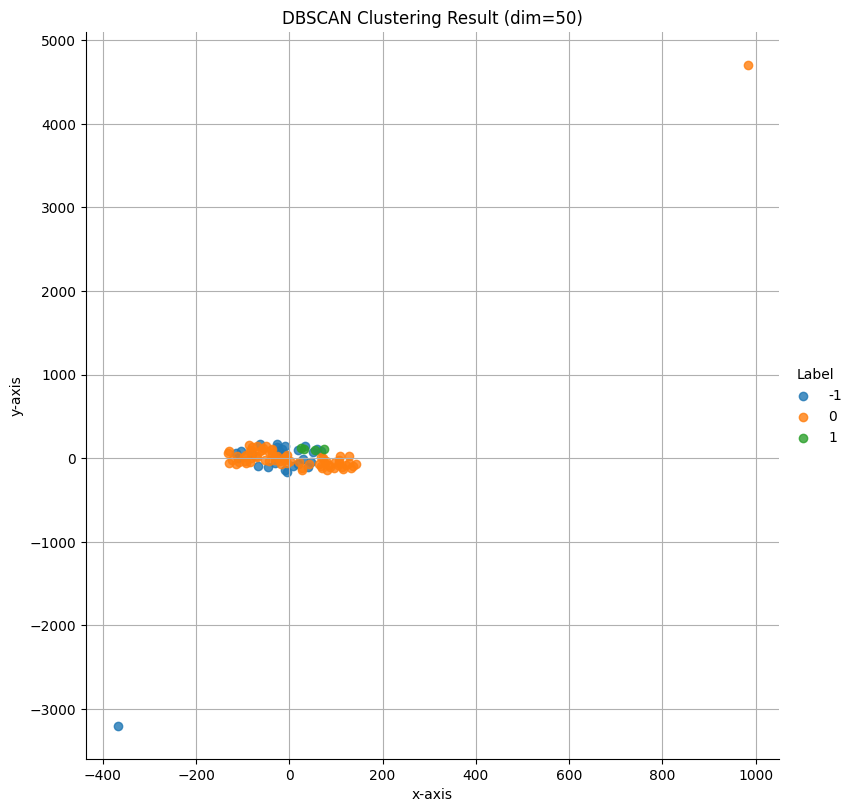

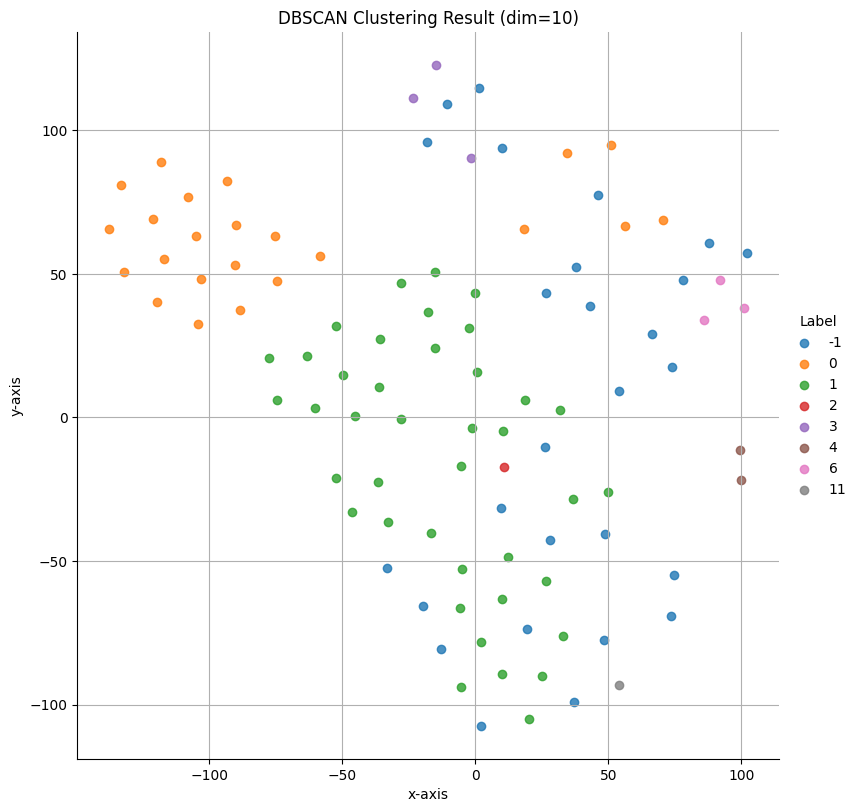

In [ ]:
for dim in [784, 100, 50, 10]:
    # 100개 샘플링 (같은 sample_idx 사용)
    X_sample = pca_data[dim][sample_idx]
    cluster_sample = dbscan_labels[dim][sample_idx]

    # t-SNE
    tSNE = TSNE(n_components=2, learning_rate=300, perplexity=30,
                early_exaggeration=12, init='random', random_state=42)
    X_tsne = pd.DataFrame(tSNE.fit_transform(X_sample))

    # DataFrame 구성
    testDF = pd.DataFrame(data=X_tsne.values, columns=["x-axis", "y-axis"])
    testDF = pd.concat((testDF, pd.Series(cluster_sample, name="Label")), axis=1)

    # 시각화
    sns.lmplot(x="x-axis", y="y-axis", hue="Label", data=testDF, fit_reg=False, height=8)
    plt.title(f"DBSCAN Clustering Result (dim={dim})")
    plt.grid()
    plt.show()